Complete the exercises below For **Assignment #6**.

Import the following items,
- `pandas as pd`,
- `LinearRegression` from the [`sklearn.linear_model`](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.linear_model) module,
- `make_column_transformer` from [`sklearn.compose`](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.compose),
- `OneHotEncoder` from [`sklearn.preprocessing`](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.preprocessing),
- `make_pipeline` from the [`sklearn.pipeline`](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.pipeline) module, and,
- everything from the [plotnine]() package.

In [1]:
import pandas as pd
from sklearn.linear_model  import LinearRegression
from sklearn.compose       import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline      import make_pipeline

## Read in our data for this exercise

Use `pd.read_csv` to read in data from the following URL: http://bit.ly/2IgDF0E. Capture the data into a dataframe called `df_voles`.

❗️Hint: just like in `R` we can read data directly from a URL.

In [2]:
df_voles = pd.read_csv('http://bit.ly/2IgDF0E')

Preview the data with the `.head()` method.

The data contains the variables:

- `site` for the id of each random study site (each case or row is a survey/trapping site)
- `voles` for the vole count at each site
- `veg` for the percent cover of vegetation at each site
- `soil` identifying a site as “moist” or “dry”

In [3]:
df_voles.head()

,site,voles,veg,soil
0,1,17,4,moist
1,2,30,33,moist
2,3,54,94,moist
3,4,49,64,moist
4,5,34,32,moist


## EDA

Let's make a few figures from `df_voles` using `ggplot` from **Plotnine**.

In the cell below plot the `voles` variable (y-axis) versus the `veg` variable and color points by the `soil` variable.

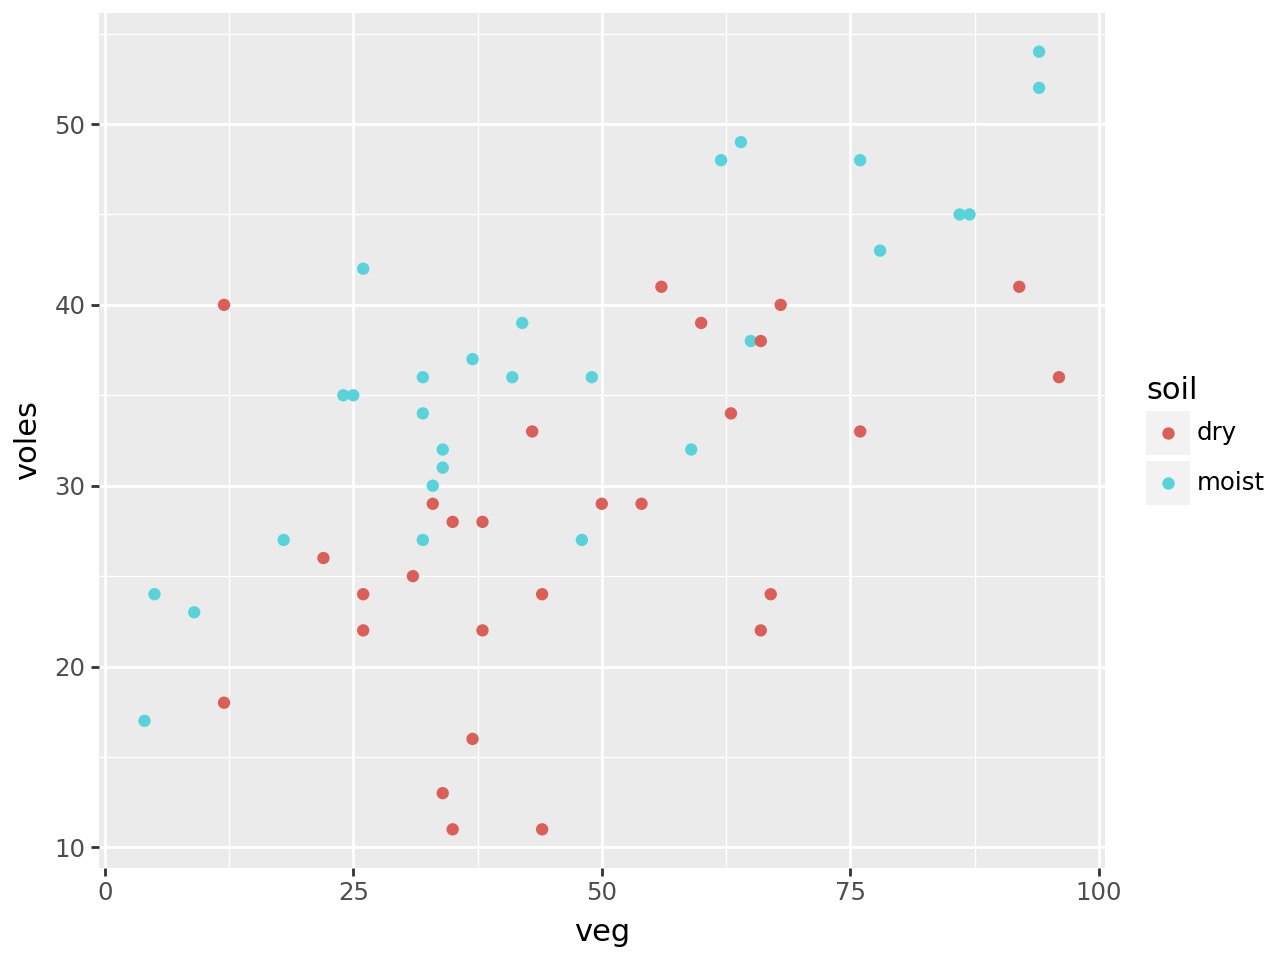

In [4]:
from plotnine import ggplot, aes, geom_point, geom_line, geom_hline

ggplot(df_voles, aes(x = 'veg', y = 'voles', color = 'soil')) + geom_point()

## Modeling

In the cell below, model `voles` with `soil` and `veg` as predictors in a parallel slopes model. 

Here are the steps I would take:
1. Make a column transformer with `make_column_transformer` that transforms `soil` with `OneHotEncoder(drop="first")` and passes 'veg' through untransformed.
2. Create a pipeline with `make_pipeline` using the column transformer from above and `LinearRegression()` as my model. 
3. Get the `X` (training data) and `y` predictor from `df_voles`
4. Use the `.fit()` method for the pipeline to train the model with `X` and `y`. 

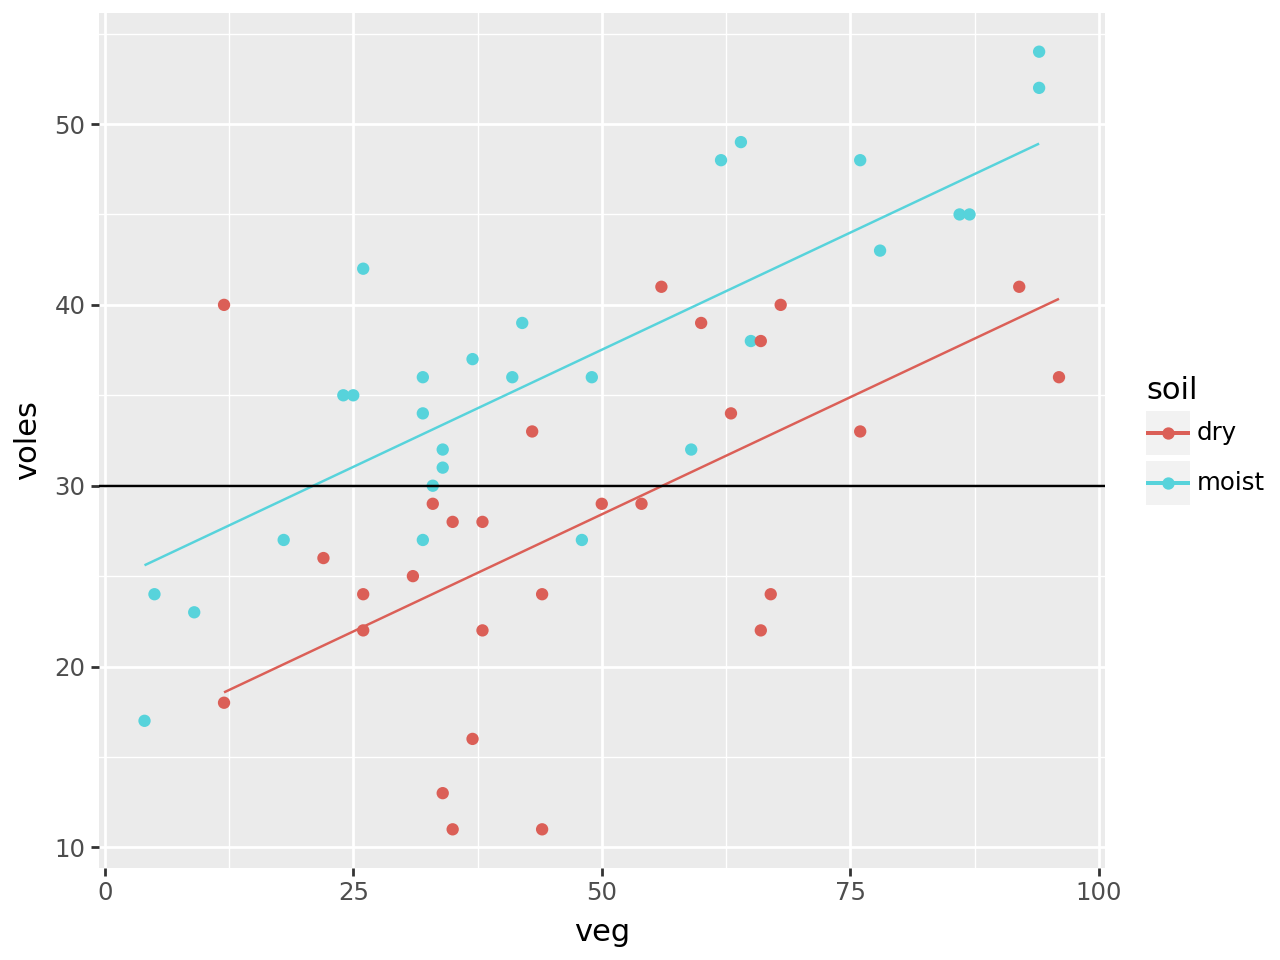

In [7]:
col_trans = make_column_transformer(
    (OneHotEncoder(drop = 'first'), ['soil']),
    ('passthrough', ['veg'])
)

vole_pipeline = make_pipeline(
    col_trans,
    LinearRegression()
)

X = df_voles[['veg', 'soil']]
y = df_voles[['voles']]

vole_pipeline.fit(X, y)

df_voles_w_predict = (
    df_voles
    .assign(pred_voles = lambda df_: vole_pipeline.predict(df_))
)

(
    ggplot(df_voles_w_predict, aes(x = 'veg', y = 'voles', color = 'soil')) +
    geom_point() +
    geom_line(aes(y = 'pred_voles')) +
    geom_hline(yintercept = 30)
)

Use the function below to get the parameter values for your model from above.

In [ ]:
def get_regression_table(pipeline):
    terms=list(pipeline['columntransformer'].get_feature_names_out()) + ['intercept']
    mod = pipeline['linearregression']
    estimates = list(mod.coef_[0]) + [mod.intercept_[0]]
    data = dict(
        term=terms, 
        estimate=estimates,
    )
    return pd.DataFrame(data)

In [ ]:
get_regression_table(vole_pipeline)

# had to add indices to the arrays in line 4 in the function defined above to get it to run

❓Would protecting a site with high vegetation cover be a more effective way to preserve the vole population than a site with low vegetation cover? Why?

(**Hint:** use your chart above to answer. It's also possible to leverage your regression parameters if you chose to model `voles` with a parallel slopes model.)

**Answer:**

Yes, protecting a site with high vegetation cover would be more effective than protecting a site with low vegetation cover.  
The coefficient for vegetation percentage in our model is 0.259069. Since the coefficient is positive, that means that as the vegetation percentage of a site increases, so does the vole population at that site.  
So in order to maximize our effectiveness, we should prioritize protecting sites with high vegetation over sites with low vegetation (within each soil humidity level).

❓Dry sites typically cost a lot less to purchase and maintain for conservation organizations. Thus, if a conservation organization decides to purchase a few dry sites, roughly what percent cover of vegetation do they need to maintain on these sites (at a minimum) to support a population of about 30 voles at the site?

(**Hint:** In your chart above, draw a line at voles = 30 using `geom_hline` and make a rough estimate for this answer...)

**Answer:**

Looking at out prediction line for dry soil, we can see that it intersects with the line at voles = 30 at around 56%.  
This means that a dry site, in order to support a population of about 30 voles, should have vegetation percentage of about 56%.

❓The Nature Conservancy is looking at purchasing a site for this species (in the same study area) that has moist soil and 40% vegetation cover. Using the regression equation what would you predict as the possible vole population the site might be able to support?

(**Hint:** Use `.predict(pd.DataFrame({"soil": ["moist"], "veg": [40]}))` with yout pipeline.)

**Answer:**

In [8]:
vole_pipeline.predict(pd.DataFrame({"soil": ["moist"], "veg": [40]}))

array([[34.92708151]])

Inputting the new values into our fitted model, we can see that the predicted value of a moist site with 40% vegetation is 34.92708151.  
So, this site can be expected to support about 35 voles.